# Balanced kmax Dataset Generation (Local PC)

This notebook generates a dataset with random `k_min` and **balanced discrete `k_max` labels**.

- Total images: `32000`
- Resolution: `128x128`
- `k_min`: random in `[1, 16]`
- `k_max`: balanced by **discrete integer label** in `[2, 64]`
- Constraint: `k_max > k_min + MIN_SEPARATION`

In [1]:
from pathlib import Path
import os
import sys
import subprocess

project_root = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
script_path = project_root / 'scripts', 'run_generation_random_both.py'
output_dir = project_root / 'data', 'raw'

print('Project root:', project_root)
print('Generator script exists:', script_path.exists())
print('Python executable:', sys.executable)

Project root: /home/davas/Documents/cnn_astro
Generator script exists: True
Python executable: /home/davas/.uve/py39/bin/python


In [2]:
# If this fails, install missing packages in this notebook kernel:
# %pip install numpy h5py pyFC

import numpy as np
import h5py
print('numpy version:', np.__version__)
print('h5py version:', h5py.__version__)

numpy version: 2.0.2
h5py version: 3.14.0


In [3]:
# Generation settings (edit if needed)
NUM_IMAGES = 32000
IMAGE_WIDTH = 128
IMAGE_HEIGHT = 128
KMIN_LOW = 1
KMIN_HIGH = 16
KMAX_LOW = 2
KMAX_HIGH = 64
MIN_SEPARATION = 2.5
BALANCED_KMAX = True
BATCH_SIZE = 256
NUM_WORKERS = max(1, (os.cpu_count() or 4) - 2)

env = os.environ.copy()
env.update({
    'NUM_IMAGES': str(NUM_IMAGES),
    'IMAGE_WIDTH': str(IMAGE_WIDTH),
    'IMAGE_HEIGHT': str(IMAGE_HEIGHT),
    'KMIN_LOW': str(KMIN_LOW),
    'KMIN_HIGH': str(KMIN_HIGH),
    'KMAX_LOW': str(KMAX_LOW),
    'KMAX_HIGH': str(KMAX_HIGH),
    'MIN_SEPARATION': str(MIN_SEPARATION),
    'BALANCED_KMAX': '1' if BALANCED_KMAX else '0',
    'BATCH_SIZE': str(BATCH_SIZE),
    'NUM_WORKERS': str(NUM_WORKERS),
})

if not script_path.exists():
    raise FileNotFoundError(f'Missing script: {script_path}')

mode_label = 'balancedkmax' if BALANCED_KMAX else 'uniformkmax'
cmd = [sys.executable, str(script_path)]
print('Running command:', ' '.join(cmd))
print('\nConfiguration:')
print(f'  - Images: {NUM_IMAGES}')
print(f'  - Resolution: {IMAGE_HEIGHT}x{IMAGE_WIDTH}')
print(f'  - k_min range: [{KMIN_LOW}, {KMIN_HIGH}]')
print(f'  - k_max range: [{KMAX_LOW}, {KMAX_HIGH}]')
print(f'  - Balanced discrete kmax labels: {BALANCED_KMAX}')
print(f'  - Min separation (kmax - kmin): {MIN_SEPARATION}')
print(f'  - Mode label: {mode_label}')
print(f'  - Batch size: {BATCH_SIZE}')
print(f'  - Workers: {NUM_WORKERS}')
print('\nThis may take a while for 32k images...')

result = subprocess.run(cmd, cwd=str(project_root), env=env, check=False)
print('Exit code:', result.returncode)
if result.returncode != 0:
    raise RuntimeError('Dataset generation failed. Check notebook output above for details.')

Running command: /home/davas/.uve/py39/bin/python /home/davas/Documents/cnn_astro/run_generation_random_both.py

Configuration:
  - Images: 32000
  - Resolution: 128x128
  - k_min range: [1, 16]
  - k_max range: [2, 64]
  - Balanced discrete kmax labels: True
  - Min separation (kmax - kmin): 2.5
  - Mode label: balancedkmax
  - Batch size: 256
  - Workers: 14

This may take a while for 32k images...
Random-k_min and Random-k_max dataset generation
Output: /home/davas/Documents/cnn_astro/generated_datasets/randomboth_balancedkmax_kmin1-16_kmax2-64_128x128_32000.h5
Images: 32000
Resolution: 128x128
k_min range: [1, 16] (uniform continuous)
k_max range: [2, 64] (balanced discrete labels)
min separation: 2.5
Workers: 14


/home/davas/.uve/py39/lib/python3.9/site-packages/pyFC/clouds.py:1229: RuntimeWarning: divide by zero encountered in power
  return np.where(np.greater_equal(np.abs(k), kmin), np.abs(k) ** (beta - 2.), 0)
/home/davas/.uve/py39/lib/python3.9/site-packages/pyFC/clouds.py:1229: RuntimeWarning: divide by zero encountered in power
  return np.where(np.greater_equal(np.abs(k), kmin), np.abs(k) ** (beta - 2.), 0)
/home/davas/.uve/py39/lib/python3.9/site-packages/pyFC/clouds.py:1229: RuntimeWarning: divide by zero encountered in power
  return np.where(np.greater_equal(np.abs(k), kmin), np.abs(k) ** (beta - 2.), 0)
/home/davas/.uve/py39/lib/python3.9/site-packages/pyFC/clouds.py:1229: RuntimeWarning: divide by zero encountered in power
  return np.where(np.greater_equal(np.abs(k), kmin), np.abs(k) ** (beta - 2.), 0)
/home/davas/.uve/py39/lib/python3.9/site-packages/pyFC/clouds.py:1229: RuntimeWarning: divide by zero encountered in power
  return np.where(np.greater_equal(np.abs(k), kmin), np.a

Batch 1/125 | 256/32000 (0.8%) | 142.03 img/s | ETA 3.7 min
Batch 2/125 | 512/32000 (1.6%) | 157.28 img/s | ETA 3.3 min
Batch 3/125 | 768/32000 (2.4%) | 164.38 img/s | ETA 3.2 min
Batch 4/125 | 1024/32000 (3.2%) | 167.57 img/s | ETA 3.1 min
Batch 5/125 | 1280/32000 (4.0%) | 169.14 img/s | ETA 3.0 min
Batch 6/125 | 1536/32000 (4.8%) | 171.20 img/s | ETA 3.0 min
Batch 7/125 | 1792/32000 (5.6%) | 173.15 img/s | ETA 2.9 min
Batch 8/125 | 2048/32000 (6.4%) | 173.28 img/s | ETA 2.9 min
Batch 9/125 | 2304/32000 (7.2%) | 174.48 img/s | ETA 2.8 min
Batch 10/125 | 2560/32000 (8.0%) | 175.36 img/s | ETA 2.8 min
Batch 11/125 | 2816/32000 (8.8%) | 176.31 img/s | ETA 2.8 min
Batch 12/125 | 3072/32000 (9.6%) | 177.22 img/s | ETA 2.7 min
Batch 13/125 | 3328/32000 (10.4%) | 177.91 img/s | ETA 2.7 min
Batch 14/125 | 3584/32000 (11.2%) | 178.39 img/s | ETA 2.7 min
Batch 15/125 | 3840/32000 (12.0%) | 179.07 img/s | ETA 2.6 min
Batch 16/125 | 4096/32000 (12.8%) | 179.15 img/s | ETA 2.6 min
Batch 17/125 | 4

Dataset file: /home/davas/Documents/cnn_astro/generated_datasets/randomboth_balancedkmax_kmin1-16_kmax2-64_128x128_32000.h5
Images shape: (32000, 128, 128)

k_min statistics:
  min/max: 1.000 / 16.000
  mean/std: 7.592 / 4.416

k_max statistics:
  min/max: 4.000 / 64.000
  mean/std: 33.997 / 17.608

Constraint k_min < k_max satisfied: True (32000/32000)
Constraint k_max > k_min + 2.5 satisfied: True (32000/32000)

Discrete k_max class-balance check:
  Number of classes: 61
  Class range: 4 -> 64
  Min/Max class count: 524 / 525
  Imbalance ratio (max/min): 1.0019

First class counts preview:
  kmax= 4 ->   525
  kmax= 5 ->   525
  kmax= 6 ->   525
  kmax= 7 ->   525
  kmax= 8 ->   525
  kmax= 9 ->   525
  kmax=10 ->   525
  kmax=11 ->   524
  kmax=12 ->   524
  kmax=13 ->   525
  kmax=14 ->   525
  kmax=15 ->   524


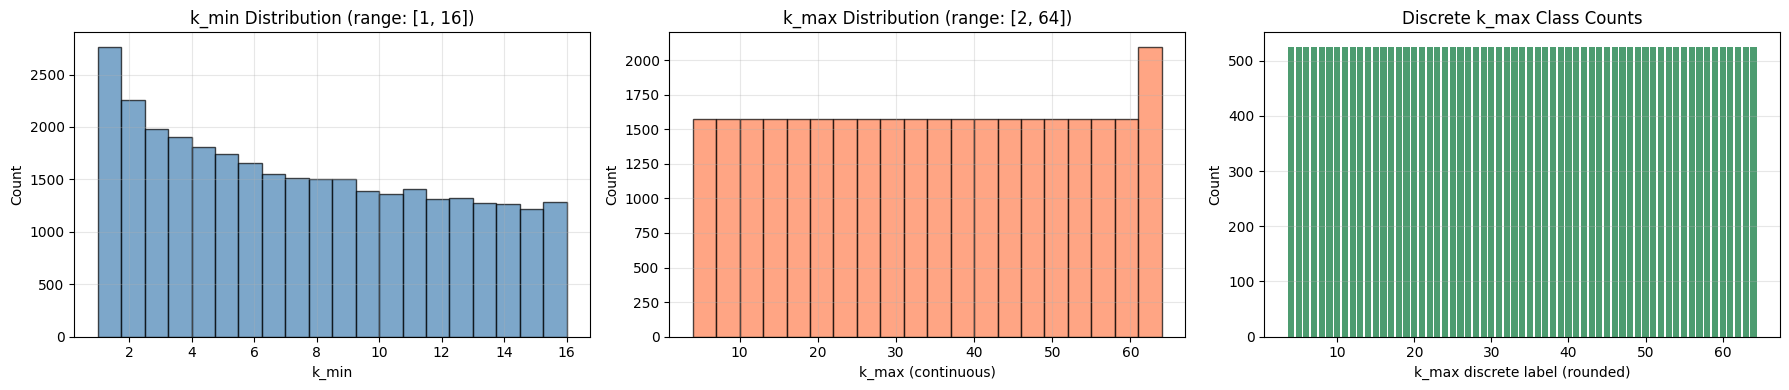

In [5]:
# Verify output file, constraints, and class-balance quality
import numpy as np
import h5py
import matplotlib.pyplot as plt

mode_label = 'balancedkmax' if BALANCED_KMAX else 'uniformkmax'
expected_name = f'randomboth_{mode_label}_kmin{KMIN_LOW}-{KMIN_HIGH}_kmax{KMAX_LOW}-{KMAX_HIGH}_{IMAGE_HEIGHT}x{IMAGE_WIDTH}_{NUM_IMAGES}.h5'
dataset_file = output_dir / expected_name

if not dataset_file.exists():
    raise FileNotFoundError(f'Expected dataset not found: {dataset_file}')

with h5py.File(dataset_file, 'r') as f:
    images_shape = f['images'].shape
    kmins = f['parameters']['k_min'][:]
    kmaxs = f['parameters']['k_max'][:]

kmax_labels = np.rint(kmaxs).astype(np.int32)
classes, counts = np.unique(kmax_labels, return_counts=True)
imbalance_ratio = float(counts.max() / max(counts.min(), 1))

sep_ok = np.all(kmaxs > (kmins + MIN_SEPARATION - 1e-6))
basic_ok = np.all(kmins < kmaxs)

print('Dataset file:', dataset_file)
print('Images shape:', images_shape)
print()
print('k_min statistics:')
print(f'  min/max: {float(kmins.min()):.3f} / {float(kmins.max()):.3f}')
print(f'  mean/std: {float(kmins.mean()):.3f} / {float(kmins.std()):.3f}')
print()
print('k_max statistics:')
print(f'  min/max: {float(kmaxs.min()):.3f} / {float(kmaxs.max()):.3f}')
print(f'  mean/std: {float(kmaxs.mean()):.3f} / {float(kmaxs.std()):.3f}')
print()
print(f'Constraint k_min < k_max satisfied: {basic_ok} ({np.sum(kmins < kmaxs)}/{len(kmins)})')
print(f'Constraint k_max > k_min + {MIN_SEPARATION} satisfied: {sep_ok} ({np.sum(kmaxs > (kmins + MIN_SEPARATION - 1e-6))}/{len(kmins)})')
print()
print('Discrete k_max class-balance check:')
print(f'  Number of classes: {len(classes)}')
print(f'  Class range: {int(classes.min())} -> {int(classes.max())}')
print(f'  Min/Max class count: {int(counts.min())} / {int(counts.max())}')
print(f'  Imbalance ratio (max/min): {imbalance_ratio:.4f}')

preview_n = min(12, len(classes))
print('\nFirst class counts preview:')
for c, n in zip(classes[:preview_n], counts[:preview_n]):
    print(f'  kmax={int(c):2d} -> {int(n):5d}')

# Histograms + discrete class counts
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(kmins, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('k_min')
axes[0].set_ylabel('Count')
axes[0].set_title(f'k_min Distribution (range: [{KMIN_LOW}, {KMIN_HIGH}])')
axes[0].grid(True, alpha=0.3)

axes[1].hist(kmaxs, bins=20, edgecolor='black', alpha=0.7, color='coral')
axes[1].set_xlabel('k_max (continuous)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'k_max Distribution (range: [{KMAX_LOW}, {KMAX_HIGH}])')
axes[1].grid(True, alpha=0.3)

axes[2].bar(classes, counts, color='seagreen', alpha=0.85)
axes[2].set_xlabel('k_max discrete label (rounded)')
axes[2].set_ylabel('Count')
axes[2].set_title('Discrete k_max Class Counts')
axes[2].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()